# ***CLEANING PHASE***

**Setup**

In [33]:
import pandas as pd

data = "/content/dirty_cafe_sales.csv"
df = pd.read_csv(data)

df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [35]:
df.shape

(10000, 8)

In [36]:
df.isna().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [37]:
df_c = df.copy()

**Transaction ID & Item**

In [38]:
df_c["Transaction ID"].duplicated().sum()

np.int64(0)

In [39]:
df_c["Item"] = df_c["Item"].str.strip().str.title()

In [40]:
df_c["Item"].isna().sum()

np.int64(333)

In [41]:
df_c.dropna(subset = "Item", inplace = True)

**Quantity**

In [42]:
df_c["Quantity"] = df_c["Quantity"].str.replace(r"[^\d.]", "", regex = True)

In [43]:
df_c["Quantity"] = pd.to_numeric(df_c["Quantity"], errors = "coerce").astype("Int64")
df_c["Quantity"].dtype

Int64Dtype()

**Price Per Unit**

In [44]:
df_c["Price Per Unit"] = df_c["Price Per Unit"].str.replace(r"[^\d.]", "", regex = True)

In [45]:
df_c["Price Per Unit"] = pd.to_numeric(df_c["Price Per Unit"], errors = "coerce")
df_c["Price Per Unit"].dtype

dtype('float64')

**Total Spent**

In [46]:
df_c["Total Spent"] = df_c["Total Spent"].str.replace(r"[^\d.]", "", regex = True)

In [47]:
df_c["Total Spent"] = pd.to_numeric(df_c["Total Spent"], errors = "coerce")
df_c["Total Spent"].dtype

dtype('float64')

**Payment Method & Location**

In [48]:
df_c["Payment Method"] = df_c["Payment Method"].str.strip().str.title()

In [49]:
df_c["Location"] = df_c["Location"].str.strip().str.title()

**Transaction Date**

In [50]:
df_c["Transaction Date"] = pd.to_datetime(df_c["Transaction Date"], errors = "coerce")
df_c["Transaction Date"].dtype

dtype('<M8[ns]')

**Result**

In [51]:
df_c.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-Store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-Store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-Store,2023-06-11


In [52]:
df_c.shape

(9667, 8)

In [53]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9667 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9667 non-null   object        
 1   Item              9667 non-null   object        
 2   Quantity          9206 non-null   Int64         
 3   Price Per Unit    9157 non-null   float64       
 4   Total Spent       9176 non-null   float64       
 5   Payment Method    7170 non-null   object        
 6   Location          6506 non-null   object        
 7   Transaction Date  9225 non-null   datetime64[ns]
dtypes: Int64(1), datetime64[ns](1), float64(2), object(4)
memory usage: 689.2+ KB


In [54]:
df_c.isna().sum()

,0
Transaction ID,0
Item,0
Quantity,461
Price Per Unit,510
Total Spent,491
Payment Method,2497
Location,3161
Transaction Date,442


# ***ANALYSIS PHASE***

**Setup**

In [55]:
import matplotlib.pyplot as plt

**1 - Which items generate the highest revenue?**

In [56]:
df_c1 = df_c.copy()
df_c1 = df_c1[df_c1["Item"] != "Unknown"]
df_c1 = df_c1[df_c1["Item"] != "Error"]

In [57]:
item_sales = df_c1.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)

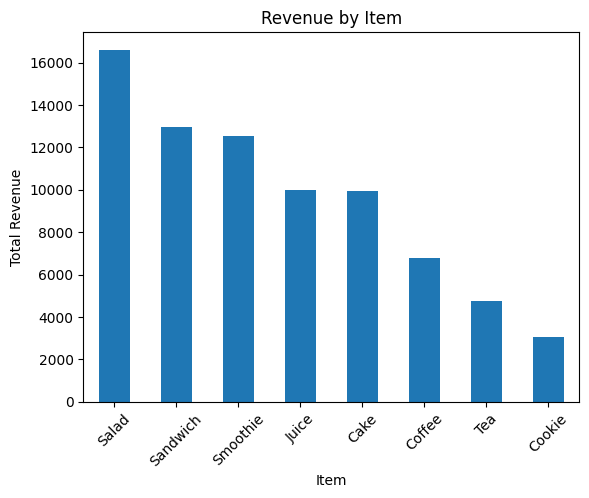

In [58]:
item_sales.plot(kind="bar")

plt.title("Revenue by Item")
plt.xlabel("Item")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()


***Salad generates the highest total revenue among all items, followed by Sandwich and Smoothie. Lower-performing items include Tea and Cookie, which contribute the least to overall sales.***

**2 - What payment method is used the most?**

In [59]:
df_c2 = df_c.copy()
df_c2 = df_c2[df_c2["Payment Method"] != "Unknown"]
df_c2 = df_c2[df_c2["Payment Method"] != "Error"]

In [60]:
item_sales = df_c2.groupby("Payment Method")["Payment Method"].value_counts().sort_values(ascending=False)

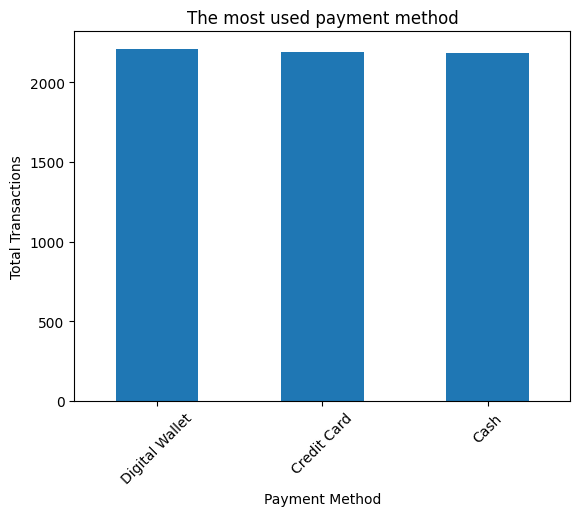

In [61]:
item_sales.plot(kind="bar")

plt.title("The most used payment method")
plt.xlabel("Payment Method")
plt.ylabel("Total Transactions")
plt.xticks(rotation=45)

plt.show()

***The analysis shows that Digital Wallet, Credit Card, and Cash are used at very similar rates. This suggests customers do not strongly prefer one payment method over another, indicating the café supports diverse payment preferences.***

**3 - Where do customers prefer to consume their orders?**

In [62]:
df_c3 = df_c.copy()
df_c3 = df_c3[df_c3["Location"] != "Unknown"]
df_c3 = df_c3[df_c3["Location"] != "Error"]

In [63]:
location_counts = df_c3["Location"].value_counts().sort_values()

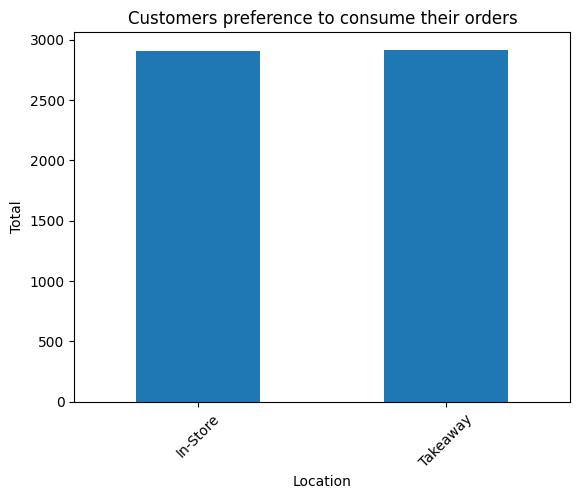

In [64]:
location_counts.plot(kind="bar")

plt.title("Customers preference to consume their orders")
plt.xlabel("Location")
plt.ylabel("Total")
plt.xticks(rotation=45)

plt.show()

***The distribution between takeaway and in-store orders is nearly equal. This indicates that customers are comfortable using both options and that the business operates effectively in both dine-in and takeaway service models.***

# ***KEY FINDINGS***

*   **Salad generated the highest total revenue among all menu items.**

*   **Payment methods (Cash, Credit Card, Digital Wallet) are used at very similar rates.**

*   **Customers order takeaway and in-store almost equally.**

# ***CONCLUSION***

**This analysis explored transaction data from a café to understand sales patterns, payment behavior, and customer order preferences. The results show balanced usage across payment methods and order locations, suggesting customers are comfortable using multiple purchasing options. Revenue distribution across menu items highlights which products contribute most to total sales.**